📁 Dataset Overview & Source

    Origin & Context:

    This dataset was created by Analytics Vidya (formerly Analytics Vidhya) for an HR Analytics Hackathon hosted in collaboration with WNS (“HR Analytics Hackathon 2018”) on their DataHack platform
    Analytics Vidhya
  
    It was later made available on Kaggle under the title “HR Analytics Classification”


    Data Collection & Purpose:
    The data originates from a contest hosted by Analytics Vidya, scraping real-world internal HR records from the company.
    
    It was used to model which employees are most likely to be promoted, helping firms identify potential promotees early and streamline promotion cycles
    .

🧾 Dataset Details

    Size:

        Dataset: 54,808 rows

    Columns & Meaning:

        employee_id – unique employee identifier

        department – department or vertical

        region – geographic region

        education – educational qualification (e.g., Bachelor's, Master's & above)

        gender – employee gender

        recruitment_channel – how they were recruited (e.g., sourcing, referred, other)

        no_of_trainings – number of trainings completed

        age – age in years

        previous_year_rating – performance rating (1–5)

        length_of_service – years in the company

        KPIs_met >80% – binary flag if KPIs ≥ 80%

        awards_won? – binary flag for awards in the past year

        avg_training_score – average score in training

        is_promoted – target label (0 = no, 1 = yes)

   

In [1]:
from google.colab import files
import pandas as pd


# Replace with actual filename
df = pd.read_csv('hr_dataset50k.csv')
df.head()


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [4]:
# Data overview
df.info()
df.describe(include='all')
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 48660 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           48660 non-null  int64  
 1   department            48660 non-null  object 
 2   region                48660 non-null  object 
 3   education             48660 non-null  object 
 4   gender                48660 non-null  object 
 5   recruitment_channel   48660 non-null  object 
 6   no_of_trainings       48660 non-null  int64  
 7   age                   48660 non-null  int64  
 8   previous_year_rating  48660 non-null  float64
 9   length_of_service     48660 non-null  int64  
 10  KPIs_met >80%         48660 non-null  int64  
 11  awards_won?           48660 non-null  int64  
 12  avg_training_score    48660 non-null  int64  
 13  is_promoted           48660 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.6+ MB


,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


In [3]:
df = df.dropna()
print("✅ Missing values dropped.")


✅ Missing values dropped.


In [ ]:
# we know from above that we have 5 features as objects and we need to convert them
 #1   department            48660 non-null  object
 #2   region                48660 non-null  object
 #3   education             48660 non-null  object
 #4   gender                48660 non-null  object
 #5   recruitment_channel   48660 non-null  object

In [5]:
categorical_cols = ['department', 'region', 'education', 'gender', 'recruitment_channel']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()


,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted,department_Finance,...,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing
0,65438,1,35,5.0,8,1,0,49,0,False,...,False,False,True,False,False,False,True,False,False,True
1,65141,1,30,5.0,4,0,0,60,0,False,...,False,False,False,False,False,False,False,True,False,False
2,7513,1,34,3.0,7,0,0,50,0,False,...,False,False,False,False,False,False,False,True,False,True
3,2542,2,39,1.0,10,0,0,50,0,False,...,False,False,False,False,False,False,False,True,False,False
4,48945,1,45,3.0,2,0,0,73,0,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
#Univariate: Numeric Features (Histograms)

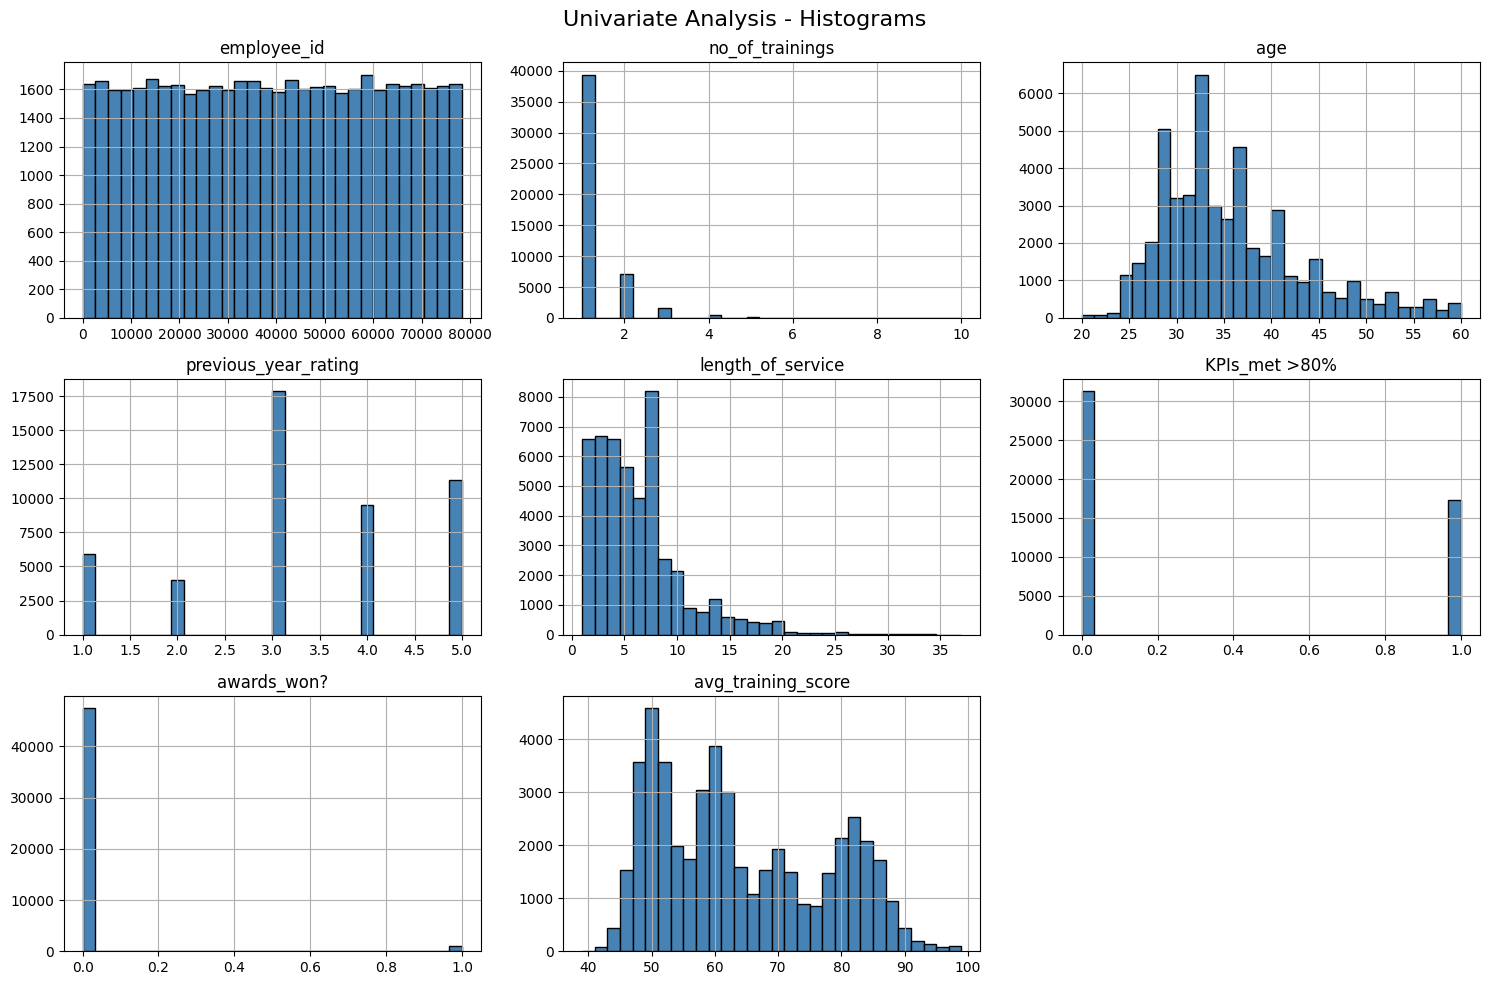

In [6]:
import matplotlib.pyplot as plt

# Only numerical columns
numeric_cols = df_encoded.select_dtypes(include='number').columns.drop('is_promoted')

df_encoded[numeric_cols].hist(bins=30, figsize=(15, 10), color='steelblue', edgecolor='black')
plt.suptitle("Univariate Analysis - Histograms", fontsize=16)
plt.tight_layout()
plt.show()


In [7]:
#Univariate: Categorical Features (Bar Plots)

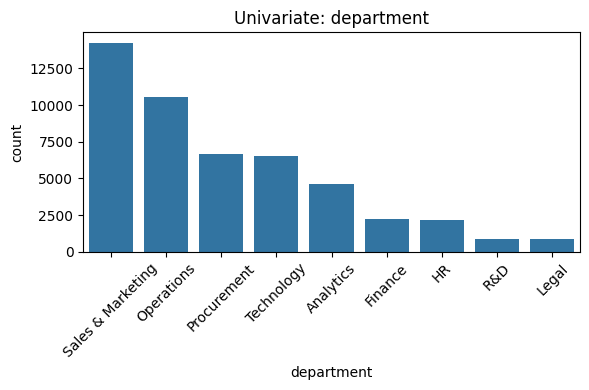

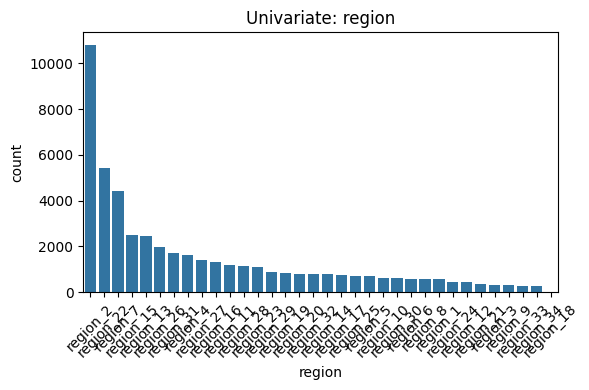

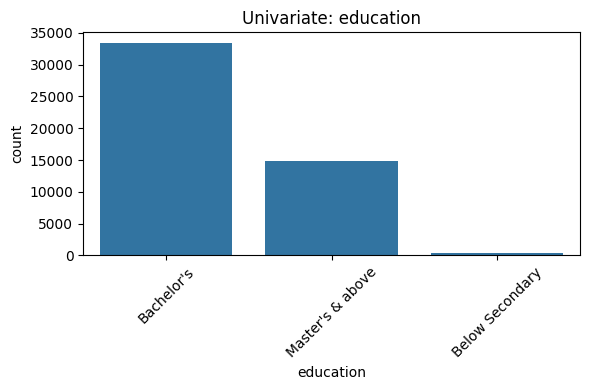

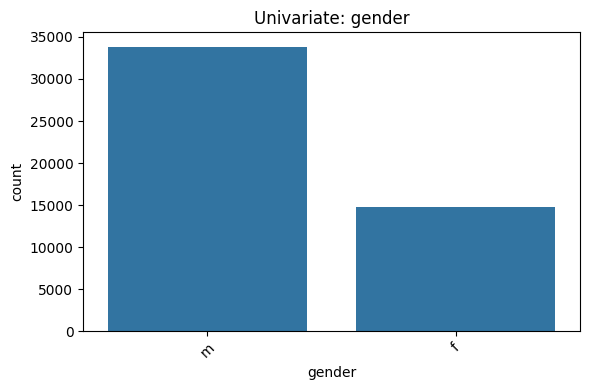

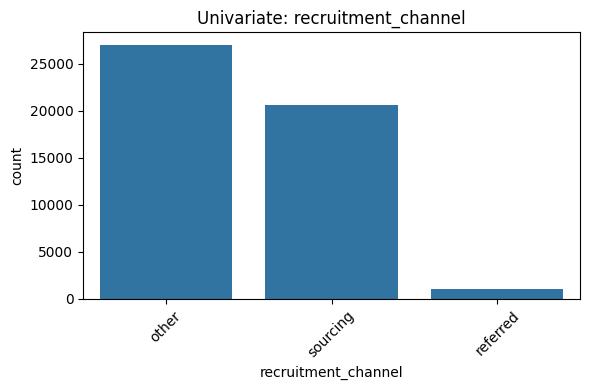

In [8]:
import seaborn as sns

# Original categorical columns before encoding
categorical = ['department', 'region', 'education', 'gender', 'recruitment_channel']

for col in categorical:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Univariate: {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
#MULTIVARIATE ANALYSIS

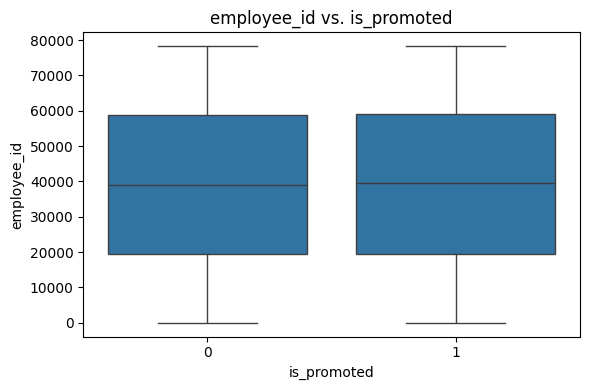

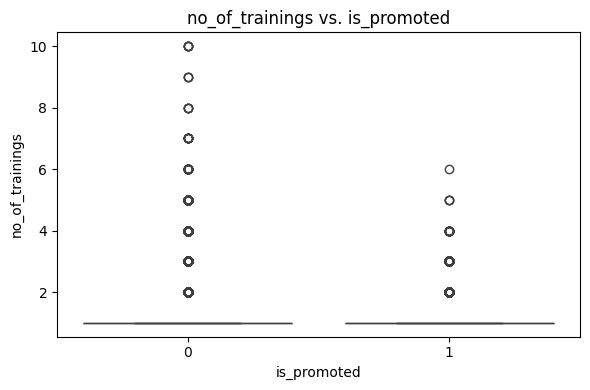

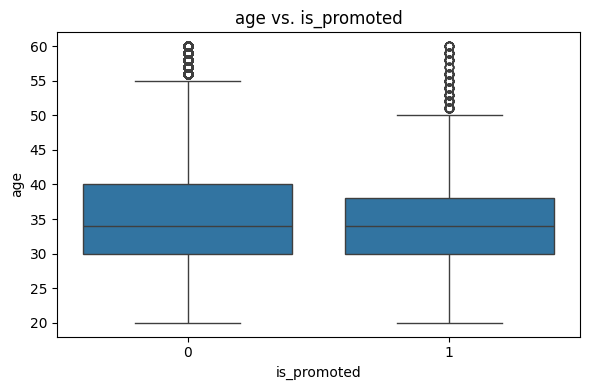

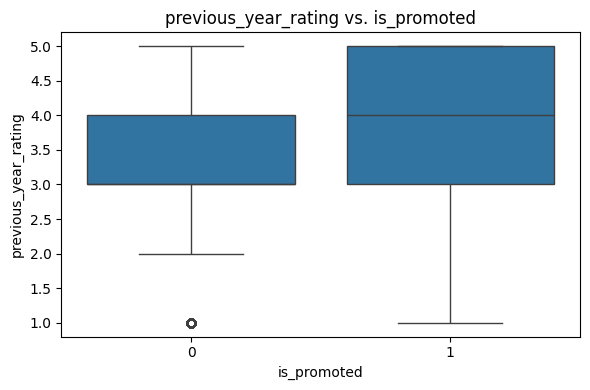

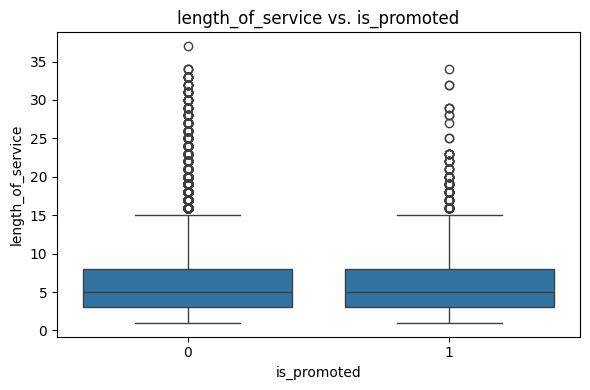

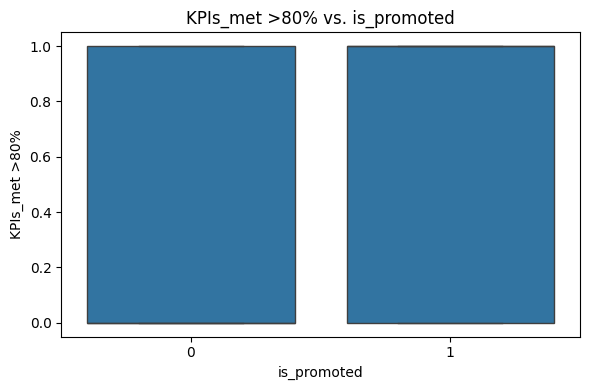

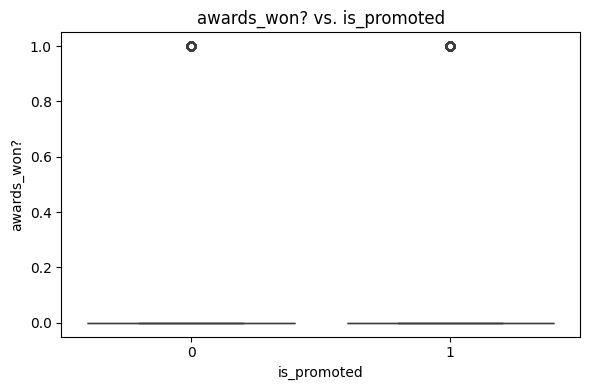

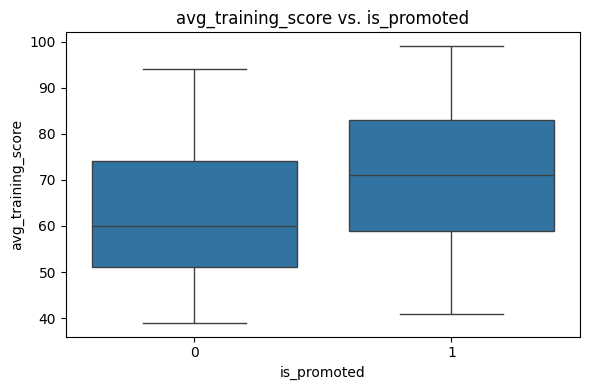

In [9]:
# Boxplots for numeric features by promotion status
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='is_promoted', y=col, data=df_encoded)
    plt.title(f"{col} vs. is_promoted")
    plt.tight_layout()
    plt.show()


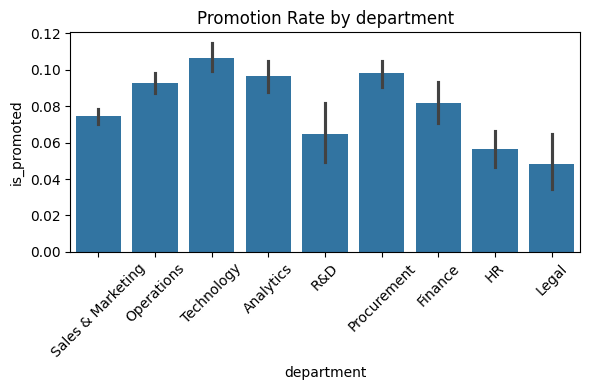

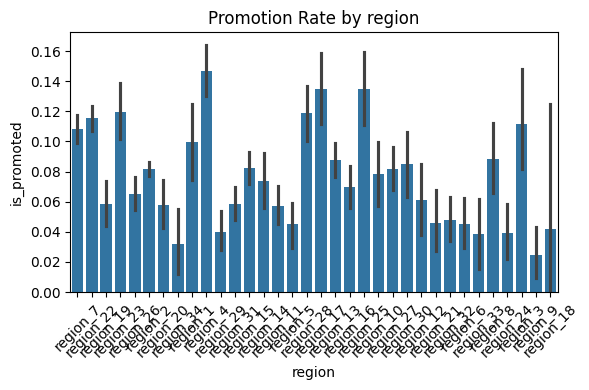

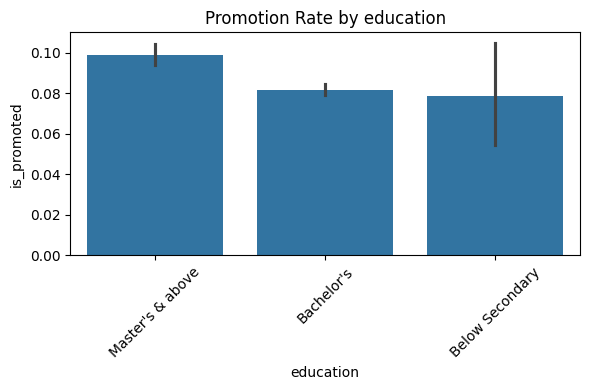

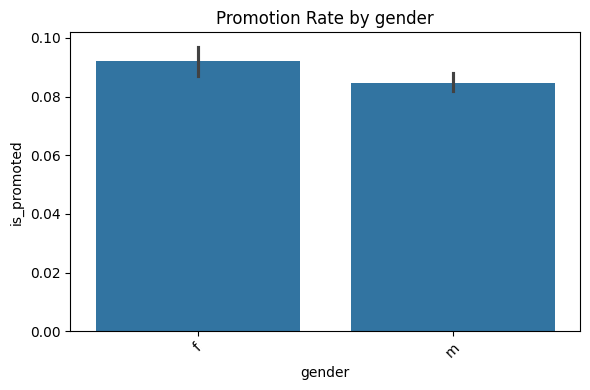

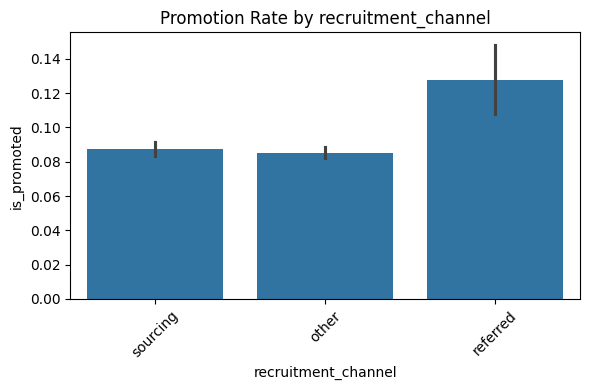

In [10]:
# Bar plot: Categorical vs promotion rate
for col in categorical:
    plt.figure(figsize=(6, 4))
    sns.barplot(x=col, y='is_promoted', data=df)
    plt.title(f"Promotion Rate by {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
#############################################################################################################################################################

In [ ]:
#EDA – Correlation Heatmap

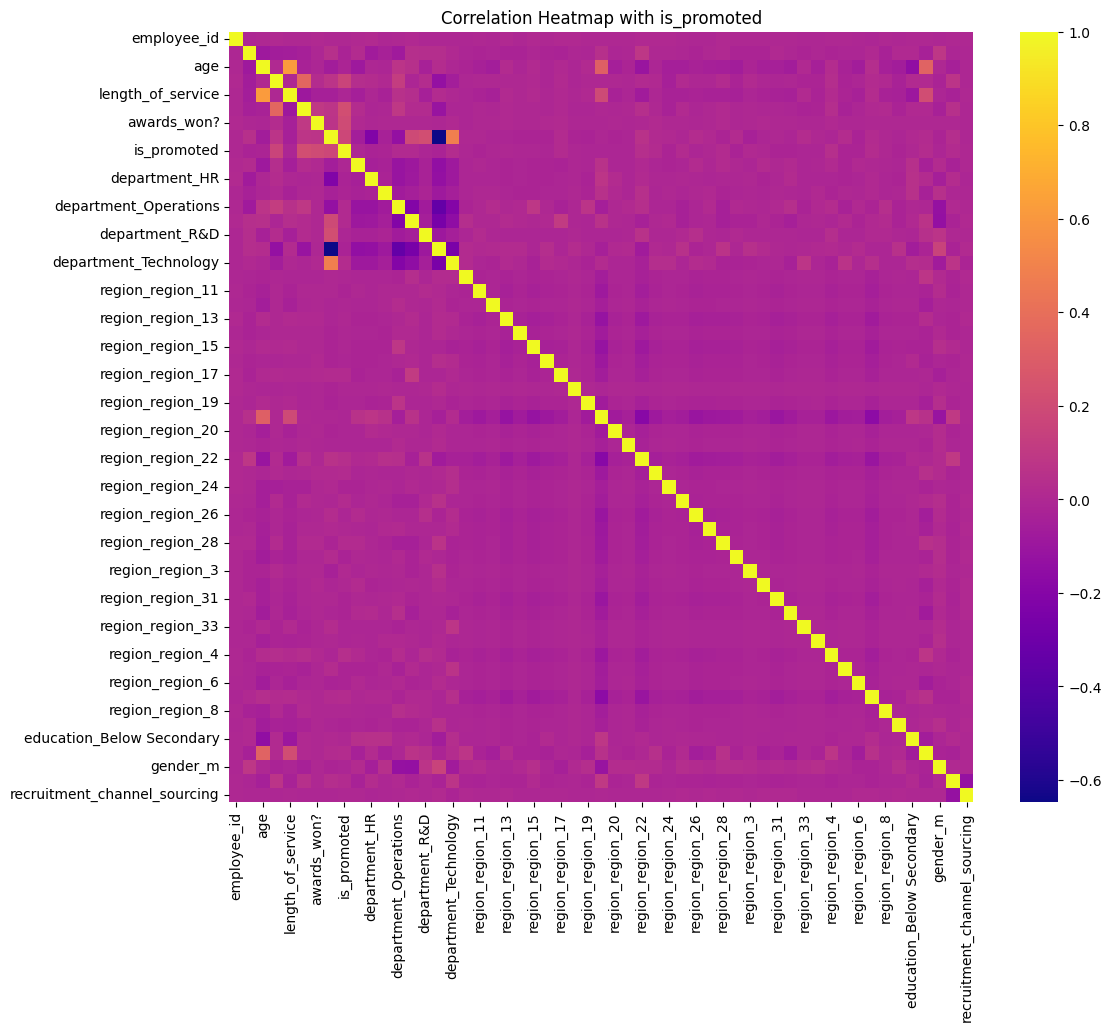

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), cmap='plasma') #inferno
plt.title("Correlation Heatmap with is_promoted")
plt.show()
#https://matplotlib.org/stable/users/explain/colors/colormaps.html

In [13]:
corr_matrix = df_encoded.corr()
top5 = corr_matrix['is_promoted'].drop('is_promoted').abs().sort_values(ascending=False).head(5)
print("Top 5 correlated features with is_promoted:")
print(top5)


Top 5 correlated features with is_promoted:
KPIs_met >80%           0.219933
awards_won?             0.196971
avg_training_score      0.179494
previous_year_rating    0.158715
region_region_4         0.039600
Name: is_promoted, dtype: float64


In [ ]:
#############################################################################################################################################################

In [ ]:
# AI Part

In [18]:
#Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('is_promoted', axis=1)
y = df_encoded['is_promoted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=100)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
lr_acc = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression Accuracy: {lr_acc:.4f}')


Logistic Regression Accuracy: 0.9109


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {rf_acc:.4f}')


Random Forest Accuracy: 0.9334


In [ ]:
#Neural Network (5 Layers, 25 Epochs)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test), epochs=10, batch_size=32)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9053 - loss: 0.2764 - val_accuracy: 0.9307 - val_loss: 0.1966
Epoch 2/10
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9332 - loss: 0.1892 - val_accuracy: 0.9353 - val_loss: 0.1828
Epoch 3/10
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9393 - loss: 0.1715 - val_accuracy: 0.9355 - val_loss: 0.1790
Epoch 4/10
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9411 - loss: 0.1654 - val_accuracy: 0.9370 - val_loss: 0.1790
Epoch 5/10
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9421 - loss: 0.1633 - val_accuracy: 0.9372 - val_loss: 0.1766
Epoch 6/10
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9405 - loss: 0.1663 - val_accuracy: 0.9364 - val_loss: 0.1761
Epoch 7/10
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9420 - loss: 0.1589 - val_accuracy: 0.9359 - val_loss: 0.1791
Epoch 8/10
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9431 - loss: 0.1566 

In [24]:
nn_acc = history.history['val_accuracy'][-1]
nn_acc

0.936600923538208

In [ ]:
#############################################################################################################################################################

In [ ]:
# video 3

In [ ]:
#Plot All Model Accuracies

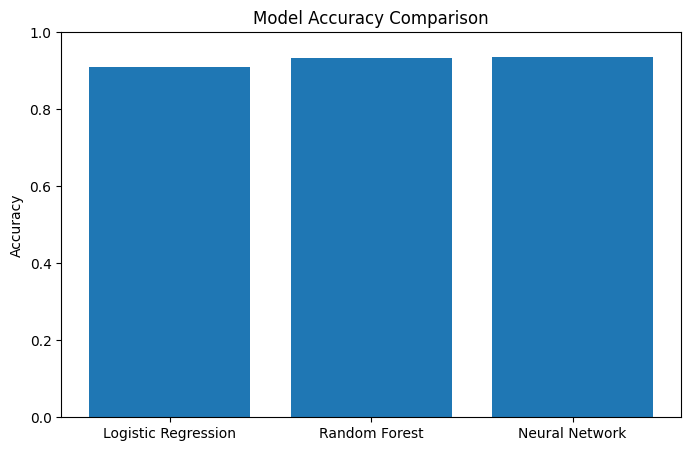

In [25]:

models = ['Logistic Regression', 'Random Forest', 'Neural Network']
accuracies = [lr_acc, rf_acc, nn_acc]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()


In [ ]:
#############################################################################################################################################################

In [ ]:
#Save Model, Scaler, and Features

In [26]:
import joblib

# Save model and preprocessing tools
model.save("hr_promotion_model.h5")
joblib.dump(scaler, "hr_scaler.pkl")
joblib.dump(X_train.columns.tolist(), "hr_features.pkl")

# Download to local machine
from google.colab import files
files.download("hr_promotion_model.h5")
files.download("hr_scaler.pkl")
files.download("hr_features.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Interactive HR Promotion Prediction Bot (Keyboard Version)

In [27]:
import tensorflow as tf
import joblib

# Load everything
model = tf.keras.models.load_model('hr_promotion_model.h5')
scaler = joblib.load(open('hr_scaler.pkl', 'rb'))
feature_columns = joblib.load(open('hr_features.pkl', 'rb'))


In [ ]:
#Define Chatbot Prediction Logic

In [28]:
import pandas as pd

def ask(prompt, type_=str):
    while True:
        try:
            return type_(input(prompt))
        except:
            print("Invalid input. Try again.")

print("📋 Enter Employee Details to Predict Promotion:\n")

# Basic features
employee_id = ask("Employee ID (just for tracking): ")
no_of_trainings = ask("Number of trainings attended: ", int)
age = ask("Age: ", int)
previous_rating = ask("Previous year rating (1–5): ", int)
length_service = ask("Length of service (years): ", int)
kpi_met = ask("KPIs met >80%? (0 or 1): ", int)
awards_won = ask("Awards won? (0 or 1): ", int)
avg_training_score = ask("Average training score (0–100): ", int)

# Categorical inputs
department = ask("Department (e.g. Sales & Marketing, Operations, Finance): ").strip()
region = ask("Region (e.g. region_1, region_22): ").strip()
education = ask("Education (e.g. Bachelor's, Master's & above, Below Secondary): ").strip()
gender = ask("Gender (m/f): ").lower()
recruitment = ask("Recruitment Channel (e.g. sourcing, referred, other): ").strip().lower()

# Build dictionary
input_dict = {
    'employee_id': int(employee_id),
    'no_of_trainings': no_of_trainings,
    'age': age,
    'previous_year_rating': previous_rating,
    'length_of_service': length_service,
    'KPIs_met >80%': kpi_met,
    'awards_won?': awards_won,
    'avg_training_score': avg_training_score,

    # One-hot categorical
    f'department_{department}': 1,
    f'region_{region}': 1,
    f'education_{education}': 1,
    f'gender_{gender}': 1,
    f'recruitment_channel_{recruitment}': 1
}


📋 Enter Employee Details to Predict Promotion:

Employee ID (just for tracking): 124555
Number of trainings attended: 15
Age: 33
Previous year rating (1–5): 4
Length of service (years): 5
KPIs met >80%? (0 or 1): 1
Awards won? (0 or 1): 1
Average training score (0–100): 88
Department (e.g. Sales & Marketing, Operations, Finance): finance
Region (e.g. region_1, region_22): region_4
Education (e.g. Bachelor's, Master's & above, Below Secondary): master
Gender (m/f): m
Recruitment Channel (e.g. sourcing, referred, other): other


In [ ]:
#Step 4: Finalize Input Vector and Predict

In [29]:
# Fill missing features with 0
for col in feature_columns:
    if col not in input_dict:
        input_dict[col] = 0

# Build input vector
input_df = pd.DataFrame([input_dict])[feature_columns]

# Scale
input_scaled = scaler.transform(input_df)

# Predict
pred = model.predict(input_scaled)[0][0]

# Output
if pred > 0.5:
    print(f"\n🎉 Prediction: EMPLOYEE WILL LIKELY BE PROMOTED (Score: {pred:.2f})")
else:
    print(f"\n📌 Prediction: EMPLOYEE WILL NOT BE PROMOTED (Score: {pred:.2f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

📌 Prediction: EMPLOYEE WILL NOT BE PROMOTED (Score: 0.08)


In [ ]:
# random forest model in depth predictions

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

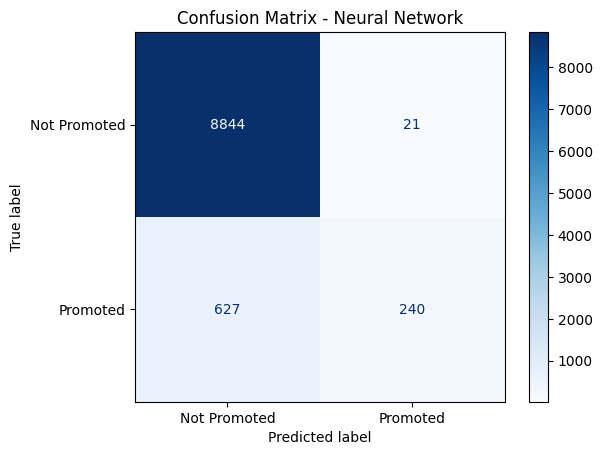

In [37]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Promoted", "Promoted"])

# Plot it
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Neural Network")
plt.show()
